# Calibration and Uncertainty Analysis

This notebook evaluates the reliability of the PyTorch MLP model beyond standard classification metrics.

The goal is to analyze whether the model's predicted risk probabilities are well calibrated and whether uncertainty estimates can help identify ambiguous or less reliable predictions.

The analysis focuses on:

- Calibration curve
- Brier score
- Probability confidence analysis
- Monte Carlo Dropout uncertainty estimation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.calibration import calibration_curve

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

## Load Dataset

The same dataset, binary target definition, train/test split, and preprocessing strategy are reused from the previous PyTorch training notebook.

This keeps the reliability analysis directly connected to the trained PyTorch MLP experiment.

In [4]:
DATA_PATH = Path("../data/diabetes_012_health_indicators_BRFSS2015.csv")

def load_diabetes_data(data_path=DATA_PATH):
    if not data_path.is_file():
        raise FileNotFoundError(
            f"Dataset not found at {data_path}. "
            "Please place the BRFSS 2015 diabetes CSV file in the data/ directory."
        )
    return pd.read_csv(data_path)

df = load_diabetes_data()

print(df.shape)
df.head()

(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
# Convert the original 3-class target into a binary clinical risk label
df["Diabetes_binary"] = (df["Diabetes_012"] > 0).astype(int)

X = df.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df["Diabetes_binary"]

X.shape, y.shape

((253680, 21), (253680,))

## Recreate Train/Test Split and Preprocessing

The same stratified train/test split and preprocessing pipeline are recreated so that the saved PyTorch model can be evaluated on the same processed test data.

The preprocessor is fit only on the training data and then applied to the held-out test data to avoid data leakage.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (202944, 21)
X_test: (50736, 21)


In [7]:
skewed_features = ["BMI"]

num_ord_features = [
    "GenHlth", "MentHlth", "PhysHlth",
    "Age", "Education", "Income"
]

binary_features = [
    "HighBP", "HighChol", "CholCheck",
    "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "skewed",
            Pipeline([
                ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("scaler", StandardScaler())
            ]),
            skewed_features
        ),
        (
            "num_ord",
            StandardScaler(),
            num_ord_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

In [8]:
# Fit preprocessing only on training data, then transform the held-out test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_test_tensor = torch.from_numpy(X_test_processed.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.to_numpy().astype(np.float32)).view(-1, 1)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_test_tensor: torch.Size([50736, 21])
y_test_tensor: torch.Size([50736, 1])


## Load Trained PyTorch MLP

The trained model parameters are loaded from the saved `state_dict`.

Because only the model weights were saved, the same model architecture must be recreated before loading the parameters.

In [9]:
class DiabetesMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [12]:
MODEL_PATH = Path("../models/pytorch_mlp_state_dict.pt")

if not MODEL_PATH.is_file():
    raise FileNotFoundError(
        f"Model state_dict not found at {MODEL_PATH}. "
        "Please run the model saving cell in 03_pytorch_mlp_training.ipynb first."
    )

input_dim = X_test_tensor.shape[1]

model = DiabetesMLP(input_dim=input_dim).to(device)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device, weights_only=True)
)

# Set model to evaluation mode
model.eval()

print(f"Loaded model from: {MODEL_PATH}")

Loaded model from: ..\models\pytorch_mlp_state_dict.pt


In [16]:
with torch.no_grad():
    logits = model(X_test_tensor.to(device))
    test_probs = torch.sigmoid(logits).cpu().numpy().ravel()

test_targets = y_test_tensor.numpy().ravel()

print("test_probs shape:", test_probs.shape)
print("test_targets shape:", test_targets.shape)
print("Probability range:", test_probs.min(), "to", test_probs.max())

test_probs shape: (50736,)
test_targets shape: (50736,)
Probability range: 0.0009100795 to 0.9828331


## Probability-Based Evaluation

Before analyzing calibration, the model's probability outputs are evaluated using two complementary metrics:

- **ROC-AUC**: Measures discrimination, or how well the model ranks at-risk individuals above non-risk individuals.
- **Brier Score**: Measures probability prediction quality by comparing predicted probabilities directly with observed binary labels.

ROC-AUC evaluates ranking performance, while Brier Score is more directly related to probability reliability. A lower Brier Score indicates better probability predictions.

In [17]:
roc_auc = roc_auc_score(test_targets, test_probs)
brier_score = brier_score_loss(test_targets, test_probs)

print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test Brier Score: {brier_score:.4f}")

Test ROC-AUC: 0.8242
Test Brier Score: 0.1804


The PyTorch MLP achieves a test ROC-AUC of 0.8242, indicating strong discrimination between at-risk and non-risk individuals.

The Brier Score is 0.1804. Unlike ROC-AUC, this score evaluates the quality of the predicted probabilities themselves, so it provides a first numerical check of probability reliability before visualizing calibration.

## Calibration Curve

A calibration curve compares predicted probabilities with observed positive rates.

Because the true individual-level risk probability is unknown, calibration is evaluated empirically by grouping samples with similar predicted probabilities.

For each probability bin:

- The x-axis shows the average predicted probability.
- The y-axis shows the observed at-risk rate.

A well-calibrated model should fall close to the diagonal line, where predicted probabilities match observed positive rates.

In [20]:
# Group predicted probabilities into bins and compare them with observed positive rates
prob_true, prob_pred = calibration_curve(
    test_targets,
    test_probs,
    n_bins=10,
    strategy="uniform"
)

calibration_results = pd.DataFrame({
    "Mean Predicted Probability": prob_pred,
    "Observed At-Risk Rate": prob_true
})

calibration_results

,Mean Predicted Probability,Observed At-Risk Rate
0,0.045431,0.010737
1,0.146515,0.033804
2,0.249078,0.058071
3,0.350832,0.097239
4,0.449720,0.131006
5,0.549801,0.182190
6,0.650987,0.255963
7,0.749618,0.340355
8,0.846082,0.481729
9,0.925081,0.667582


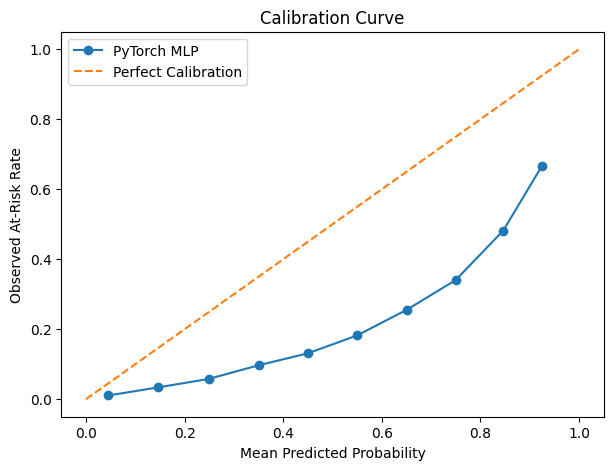

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(prob_pred, prob_true, marker="o", label="PyTorch MLP")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed At-Risk Rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

The calibration table shows that the PyTorch MLP overestimates risk across all probability bins.

For example, samples with an average predicted probability around 0.55 have an observed at-risk rate of only about 0.18, and samples with an average predicted probability around 0.85 have an observed at-risk rate of about 0.48.

This indicates that the model's probability scores are not well calibrated, even though its ROC-AUC shows useful ranking performance. One possible reason is the use of class-weighted binary cross-entropy, which encourages the model to pay more attention to the minority at-risk class. This helps improve sensitivity, but it can also shift predicted probabilities upward and lead to risk overestimation.

This reinforces the importance of evaluating calibration separately from discrimination metrics such as ROC-AUC.

## Probability Distribution

The distribution of predicted risk probabilities helps show how the model assigns risk scores across the test set.

This is useful for understanding whether the model tends to make uncertain predictions near 0.5 or more confident predictions closer to 0 or 1.

Because the calibration analysis showed that the model overestimates risk, this distribution can also help reveal whether many predictions are shifted toward higher risk probabilities.

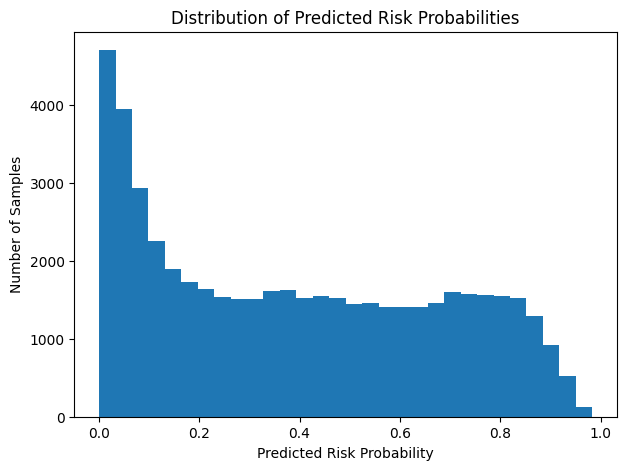

In [24]:
plt.figure(figsize=(7, 5))

plt.hist(test_probs, bins=30)

plt.xlabel("Predicted Risk Probability")
plt.ylabel("Number of Samples")
plt.title("Distribution of Predicted Risk Probabilities")
plt.show()

In [26]:
probability_summary = pd.Series(test_probs).describe()

probability_summary

count    50736.000000
mean         0.390634
std          0.284723
min          0.000910
25%          0.114586
50%          0.362935
75%          0.642087
max          0.982833
dtype: float64

The probability distribution shows that many samples receive relatively low predicted risk probabilities, which is expected because the dataset contains more non-risk than at-risk individuals.

However, the distribution is not concentrated only near zero. The model assigns a wide range of risk scores across the test set, including many probabilities in the middle and upper ranges.

This plot should be interpreted together with the calibration table. While the distribution shows where the model places its predictions, the calibration results show that those probabilities tend to overestimate the observed at-risk rate across all probability bins.

## Post-hoc Calibration with Platt Scaling

The calibration analysis showed that the raw PyTorch MLP probabilities overestimate the observed at-risk rate across all probability bins.

To test whether probability reliability can be improved after training, Platt scaling is applied as a post-hoc calibration method.

Platt scaling fits a logistic regression model on validation-set predicted probabilities. The trained calibrator then maps raw model probabilities to calibrated probabilities.

The calibrator is fit only on validation data and then applied to the held-out test probabilities.

In [35]:
from sklearn.linear_model import LogisticRegression

# Recreate the same neural network train/validation split used in the training notebook
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_val_tensor = torch.from_numpy(X_val_nn.astype(np.float32))

# LogisticRegression expects class labels as array-like values
y_val_array = y_val_nn.to_numpy().astype(int)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_array:", y_val_array.shape)

X_val_tensor: torch.Size([40589, 21])
y_val_array: (40589,)


In [34]:
model.eval()

with torch.no_grad():
    val_logits = model(X_val_tensor.to(device))
    val_probs = torch.sigmoid(val_logits).cpu().numpy().ravel()

print("val_probs shape:", val_probs.shape)
print("Validation probability range:", val_probs.min(), "to", val_probs.max())

val_probs shape: (40589,)
Validation probability range: 0.00085528835 to 0.98407817


## Fit Platt Scaling Calibrator

The Platt scaling calibrator is trained using validation-set model probabilities as input and validation labels as targets.

This calibrator learns a simple mapping from raw PyTorch probability scores to better-calibrated probability estimates.

In [38]:
platt_calibrator = LogisticRegression()

platt_calibrator.fit(
    val_probs.reshape(-1, 1),
    y_val_array
)

# Apply the validation-fitted calibrator to held-out test probabilities
test_probs_calibrated = platt_calibrator.predict_proba(
    test_probs.reshape(-1, 1)
)[:, 1]

print("Original probability range:", test_probs.min(), "to", test_probs.max())
print("Calibrated probability range:", test_probs_calibrated.min(), "to", test_probs_calibrated.max())

Original probability range: 0.0009100795 to 0.9828331
Calibrated probability range: 0.014740541335813383 to 0.6502306059037495


Platt scaling compresses the predicted probability range from approximately 0.001–0.983 to approximately 0.015–0.650.

This is consistent with the earlier calibration analysis, which showed that the raw PyTorch MLP probabilities overestimated the observed at-risk rate across all probability bins. The calibrator adjusts the probability scale downward while preserving the model's ranking structure.

## Calibration Before and After Platt Scaling

The original PyTorch MLP probabilities and Platt-calibrated probabilities are compared using ROC-AUC, Brier Score, and calibration curves.

Post-hoc calibration mainly changes the probability scale. It should improve probability reliability if successful, but it may not substantially change ROC-AUC because ROC-AUC depends mostly on ranking.

In [40]:
metrics_calibration_comparison = pd.DataFrame({
    "Original PyTorch Probabilities": {
        "ROC-AUC": roc_auc_score(test_targets, test_probs),
        "Brier score": brier_score_loss(test_targets, test_probs)
    },
    "Platt-Calibrated Probabilities": {
        "ROC-AUC": roc_auc_score(test_targets, test_probs_calibrated),
        "Brier score": brier_score_loss(test_targets, test_probs_calibrated)
    }
})

metrics_calibration_comparison

,Original PyTorch Probabilities,Platt-Calibrated Probabilities
ROC-AUC,0.824194,0.824194
Brier score,0.180412,0.106297


Platt scaling substantially improves the Brier Score from 0.1804 to 0.1063, indicating that the calibrated probabilities are closer to the observed binary outcomes.

ROC-AUC remains unchanged at 0.8242 because Platt scaling mainly rescales the probability values without changing the ranking of individuals. This means the model's discrimination ability is preserved while its probability estimates become more reliable.

This result supports the idea that the raw PyTorch MLP learned useful risk rankings, but its uncalibrated probabilities overestimated risk. Post-hoc calibration improves the interpretability of the risk probabilities without retraining the neural network.

In [45]:
# Compute calibration curve for calibrated probabilities
prob_true_calibrated, prob_pred_calibrated = calibration_curve(
    test_targets,
    test_probs_calibrated,
    n_bins=10,
    strategy="uniform"
)

calibration_results_calibrated = pd.DataFrame({
    "Mean Predicted Probability": prob_pred_calibrated,
    "Observed At-Risk Rate": prob_true_calibrated
})

calibration_results_calibrated

,Mean Predicted Probability,Observed At-Risk Rate
0,0.037756,0.040582
1,0.144682,0.151519
2,0.248308,0.235941
3,0.349346,0.325213
4,0.449095,0.433394
5,0.541926,0.560965
6,0.615561,0.755020


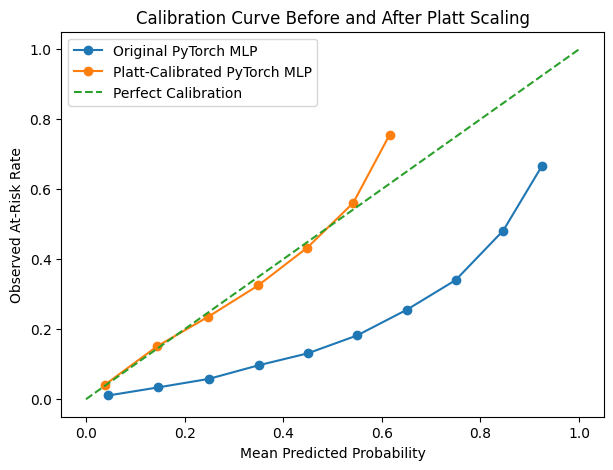

In [48]:
plt.figure(figsize=(7, 5))

plt.plot(prob_pred, prob_true, marker="o", label="Original PyTorch MLP")
plt.plot(
    prob_pred_calibrated,
    prob_true_calibrated,
    marker="o",
    label="Platt-Calibrated PyTorch MLP"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed At-Risk Rate")
plt.title("Calibration Curve Before and After Platt Scaling")
plt.legend()
plt.show()

After Platt scaling, the calibration table shows much closer agreement between mean predicted probabilities and observed at-risk rates across most bins.

This is consistent with the improved Brier Score, which decreased from 0.1804 to 0.1063. The calibrated probabilities are no longer systematically above the observed at-risk rates, suggesting that post-hoc calibration substantially reduces the risk overestimation seen in the raw PyTorch MLP outputs.

However, the highest calibrated probability bin shows underestimation: samples with an average calibrated probability around 0.62 have an observed at-risk rate around 0.76. This is important in a clinical screening context because underestimating risk among high-risk individuals could lead to risk scores that appear less urgent than the observed outcomes suggest.

Therefore, Platt scaling improves overall probability reliability, but the highest-risk region still requires careful interpretation. Additional calibration methods, such as isotonic regression or calibration with more data, could be explored in future work.

The calibrated table contains fewer than 10 bins because Platt scaling compressed the probability range to approximately 0.015–0.650, leaving no samples in the highest probability bins.

## Monte Carlo Dropout Uncertainty

Monte Carlo Dropout is used as a lightweight uncertainty estimation method.

During standard evaluation, dropout layers are turned off using `model.eval()`, which produces one deterministic prediction for each sample.

For Monte Carlo Dropout, dropout layers are kept active during inference. The same test samples are passed through the model multiple times, producing slightly different probability estimates.

For each sample:

- The mean predicted probability is used as the average risk estimate.
- The standard deviation of predicted probabilities is used as an uncertainty proxy.

This does not fully model uncertainty over the neural network parameters, but it provides a practical approximation by measuring how much predictions change when dropout is repeatedly applied during inference.

MC Dropout is applied to the raw PyTorch probability outputs, not the Platt-calibrated probabilities. The goal is to estimate prediction instability from the neural network itself.

In [53]:
def enable_dropout(model):
    """
    Enable dropout layers during inference while keeping the rest of the model unchanged.
    """
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def mc_dropout_predict(model, X_tensor, device, n_passes=50):
    """
    Run multiple stochastic forward passes with dropout enabled.

    Returns:
        mean_probs: average predicted probability across passes
        std_probs: standard deviation of predicted probabilities across passes
        all_probs: all stochastic probability predictions
    """
    model.eval()
    enable_dropout(model)

    all_probs = []

    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(X_tensor.to(device))
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.append(probs)
    
    all_probs = np.vstack(all_probs)

    mean_probs = all_probs.mean(axis=0)
    std_probs = all_probs.std(axis=0)

    # Restore standard evaluation mode after MC Dropout inference
    model.eval()

    return mean_probs, std_probs, all_probs

In [57]:
mc_mean_probs, mc_std_probs, mc_all_probs = mc_dropout_predict(
    model=model,
    X_tensor=X_test_tensor,
    device=device,
    n_passes=50
)

print("MC mean probability range:", mc_mean_probs.min(), "to", mc_mean_probs.max())
print("MC uncertainty range:", mc_std_probs.min(), "to", mc_std_probs.max())
print("MC predictions shape:", mc_all_probs.shape)

MC mean probability range: 0.0014334633 to 0.98026985
MC uncertainty range: 0.0015109748 to 0.1616256
MC predictions shape: (50, 50736)
